## 📘 02_Cleaning.ipynb

1️⃣ Import des librairies

In [4]:
import pandas as pd
import numpy as np

2️⃣ Charger tous les datasets

In [5]:
df_population = pd.read_csv("../Shets/Table 1. Population size in eac.csv")
df_transport = pd.read_csv("../Shets/Table 2. Number of Tram and Bus.csv")
df_roads = pd.read_csv("../Shets/Table 3. Type of roads.csv")
df_land = pd.read_csv("../Shets/Table 4. Land use variables.csv")

3️⃣ Nettoyer les noms de colonnes

In [6]:
def clean_columns(df):
    df.columns = (
        df.columns
        .str.strip()
        .str.lower()
        .str.replace(" ", "_")
        .str.replace("(", "")
        .str.replace(")", "")
    )
    return df

In [7]:
df_population = clean_columns(df_population)
df_transport = clean_columns(df_transport)
df_roads = clean_columns(df_roads)
df_land = clean_columns(df_land)

4️⃣ Vérifier les valeurs manquantes

In [8]:
df_population.isnull().sum()
df_transport.isnull().sum()
df_roads.isnull().sum()
df_land.isnull().sum()

commune                            0
zip_code                           0
region_area_m²                     0
parking_area_m²                    0
industrial_area__m²                0
parks_area__m²                     0
residential_area_m²                0
university/_institution_area_m²    0
number_of_commercial_buildings     0
dtype: int64

5️⃣ Vérifier les types de données

In [9]:
df_population.info()
print("\n")
df_transport.info()
print("\n")
df_roads.info()
print("\n")
df_land.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22 entries, 0 to 21
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   commune          22 non-null     object 
 1   zip_code         22 non-null     int64  
 2   population_size  22 non-null     float64
 3   household        22 non-null     float64
 4   density          22 non-null     float64
dtypes: float64(3), int64(1), object(1)
memory usage: 1012.0+ bytes


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22 entries, 0 to 21
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   commune       22 non-null     object
 1   zip_code      22 non-null     int64 
 2   tram-station  22 non-null     int64 
 3   bus-station   22 non-null     int64 
dtypes: int64(3), object(1)
memory usage: 836.0+ bytes


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22 entries, 0 to 21
Data columns (total 5 col

6️⃣ Nettoyer les communes

In [10]:
def clean_commune(df):
    df["commune"] = df["commune"].str.strip().str.lower()
    return df

In [11]:
df_population = clean_commune(df_population)
df_transport = clean_commune(df_transport)
df_roads = clean_commune(df_roads)
df_land = clean_commune(df_land)

8️⃣ Sauvegarder les datasets propres

In [12]:
df_population.to_csv("../data_clean/population_clean.csv", index=False)
df_transport.to_csv("../data_clean/transport_clean.csv", index=False)
df_roads.to_csv("../data_clean/roads_clean.csv", index=False)
df_land.to_csv("../data_clean/landuse_clean.csv", index=False)

📘 02_Cleaning — Données trafic

1️⃣ Charger les fichiers Monday → Sunday

In [13]:
import pandas as pd

days = {
    "Monday": "Table 5. Monday.csv",
    "Tuesday": "Table 6. Tuesday.csv",
    "Wednesday": "Table 7. Wednesday.csv",
    "Thursday": "Table. 8 Thursday.csv",
    "Friday": "Table. 9 Friday.csv",
    "Saturday": "Table. 10 Saturday.csv",
    "Sunday": "Table. 11 Sunday.csv"
}

traffic_data = {}

for day, file in days.items():
    
    df = pd.read_csv(f"../Shets/{file}")
    
    # nettoyer colonnes
    df.columns = df.columns.str.strip().str.lower()
    
    # ajouter jour
    df["day"] = day
    
    traffic_data[day] = df

2️⃣ Fusionner tous les jours

In [14]:
df_traffic = pd.concat(traffic_data.values(), ignore_index=True)

df_traffic.head()

InvalidIndexError: Reindexing only valid with uniquely valued Index objects

solution

In [ ]:
days = {
    "Monday": "Table 5. Monday.csv",
    "Tuesday": "Table 6. Tuesday.csv",
    "Wednesday": "Table 7. Wednesday.csv",
    "Thursday": "Table. 8 Thursday.csv",
    "Friday": "Table. 9 Friday.csv",
    "Saturday": "Table. 10 Saturday.csv",
    "Sunday": "Table. 11 Sunday.csv"
}

traffic_data = {}

for day, file in days.items():

    df = pd.read_csv(f"../Shets/{file}")
    
    df = clean_columns(df)   # nettoyer les colonnes
    df["day"] = day          # ajouter le jour
    
    traffic_data[day] = df   # ⚡ IMPORTANT

certaines colonnes sont dupliquées dans tes fichiers CSV.

In [ ]:
for day, file in days.items():

    df = pd.read_csv(f"../Shets/{file}")

    df = clean_columns(df)

    df = df.loc[:, ~df.columns.duplicated()]   # ⭐ corrige l'erreur

    df["day"] = day

    traffic_data[day] = df

In [ ]:
## Ensuite concaténer
df_traffic = pd.concat(traffic_data.values(), ignore_index=True)

df_traffic.head()

,commune,zip_code,index,coordinates_debut,latitude_debut,longitude_debut,index.1,coordinates_fin,latitude_fin,longitude_fin,...,tti_min_at_15,tti_min_at_16,tti_min_at_17,tti_min_at_19,tti_min_at_20,tti_min_at_21,tti_min_at_22,tti_min_at_23,trt_min_at,tti_min_at
0,Echchallalate,28822,0,"33.56968640878232,-7.395306348809435",33.569686,-7.395306,1.0,"33.64792053315948,-7.408108582535458",33.647921,-7.408109,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Echchallalate,28822,0,"33.56968640878232,-7.395306348809435",33.569686,-7.395306,2.0,"33.615365940406214,-7.458959071198275",33.615366,-7.458959,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Echchallalate,28822,0,"33.56968640878232,-7.395306348809435",33.569686,-7.395306,3.0,"33.62789799357488,-7.44403942378749",33.627898,-7.444039,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Echchallalate,28822,0,"33.56968640878232,-7.395306348809435",33.569686,-7.395306,4.0,"33.601050398663844,-7.4844428526403695",33.601050,-7.484443,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Echchallalate,28822,1,"33.64792053315948,-7.408108582535458",33.647921,-7.408109,0.0,"33.56968640878232,-7.395306348809435",33.569686,-7.395306,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
## verification des colones dubliquee
df.columns[df.columns.duplicated()]

Index([], dtype='object')

## --------------------------------------------------

In [ ]:
df_test = pd.read_csv("../Shets/Table 5. Monday.csv")
df_test.head()

,COMMUNE,ZIP code,index,Coordinates Debut,Latitude Debut,Longitude Debut,index.1,Coordinates Fin,Latitude Fin,Longitude Fin,...,TTI (min) at 14,TTI (min) at 15,TTI (min) at 16,TTI (min) at 17,TTI (min) at 18,TTI (min) at 19,TTI (min) at 20,TTI (min) at 21,TTI (min) at 22,TTI (min) at 23
0,Echchallalate,28822,0,"33.56968640878232,-7.395306348809435",33.569686,-7.395306,1,"33.64792053315948,-7.408108582535458",33.647921,-7.408109,...,1.024714,1.028062,1.024714,1.038109,1.034760,1.049829,1.026388,1.033086,1.029737,1.024714
1,Echchallalate,28822,0,"33.56968640878232,-7.395306348809435",33.569686,-7.395306,2,"33.615365940406214,-7.458959071198275",33.615366,-7.458959,...,1.395911,1.390415,1.401407,1.405071,1.388584,1.331795,1.317139,1.317139,1.322635,1.443541
2,Echchallalate,28822,0,"33.56968640878232,-7.395306348809435",33.569686,-7.395306,3,"33.62789799357488,-7.44403942378749",33.627898,-7.444039,...,1.213427,1.217207,1.230438,1.237998,1.236108,1.258789,1.241778,1.241778,1.237998,1.226658
3,Echchallalate,28822,0,"33.56968640878232,-7.395306348809435",33.569686,-7.395306,4,"33.601050398663844,-7.4844428526403695",33.601050,-7.484443,...,1.290248,1.290248,1.306088,1.313288,1.310408,1.320488,1.298888,1.298888,1.297448,1.297448
4,Echchallalate,28822,1,"33.64792053315948,-7.408108582535458",33.647921,-7.408109,0,"33.56968640878232,-7.395306348809435",33.569686,-7.395306,...,1.076619,1.093363,1.111781,1.103409,1.110106,1.098386,1.098386,1.098386,1.098386,1.091688


In [ ]:
df_test = pd.read_csv("../Shets/Table 5. Monday.csv")
df_test.head()

,COMMUNE,ZIP code,index,Coordinates Debut,Latitude Debut,Longitude Debut,index.1,Coordinates Fin,Latitude Fin,Longitude Fin,...,TTI (min) at 14,TTI (min) at 15,TTI (min) at 16,TTI (min) at 17,TTI (min) at 18,TTI (min) at 19,TTI (min) at 20,TTI (min) at 21,TTI (min) at 22,TTI (min) at 23
0,Echchallalate,28822,0,"33.56968640878232,-7.395306348809435",33.569686,-7.395306,1,"33.64792053315948,-7.408108582535458",33.647921,-7.408109,...,1.024714,1.028062,1.024714,1.038109,1.034760,1.049829,1.026388,1.033086,1.029737,1.024714
1,Echchallalate,28822,0,"33.56968640878232,-7.395306348809435",33.569686,-7.395306,2,"33.615365940406214,-7.458959071198275",33.615366,-7.458959,...,1.395911,1.390415,1.401407,1.405071,1.388584,1.331795,1.317139,1.317139,1.322635,1.443541
2,Echchallalate,28822,0,"33.56968640878232,-7.395306348809435",33.569686,-7.395306,3,"33.62789799357488,-7.44403942378749",33.627898,-7.444039,...,1.213427,1.217207,1.230438,1.237998,1.236108,1.258789,1.241778,1.241778,1.237998,1.226658
3,Echchallalate,28822,0,"33.56968640878232,-7.395306348809435",33.569686,-7.395306,4,"33.601050398663844,-7.4844428526403695",33.601050,-7.484443,...,1.290248,1.290248,1.306088,1.313288,1.310408,1.320488,1.298888,1.298888,1.297448,1.297448
4,Echchallalate,28822,1,"33.64792053315948,-7.408108582535458",33.647921,-7.408109,0,"33.56968640878232,-7.395306348809435",33.569686,-7.395306,...,1.076619,1.093363,1.111781,1.103409,1.110106,1.098386,1.098386,1.098386,1.098386,1.091688


1️⃣ Voir les colonnes TTI

In [ ]:
[c for c in df_test.columns if "tti" in c.lower()]

['TTI (min) at 0',
 'TTI (min) at  1',
 'TTI (min) at  2',
 'TTI (min) at  3',
 'TTI (min) at  4',
 'TTI (min) at  5',
 'TTI (min) at  6',
 'TTI (min) at  7',
 'TTI (min) at  8',
 'TTI (min) at  9',
 'TTI (min) at  10',
 'TTI (min) at  11',
 'TTI (min) at  12',
 'TTI (min) at  13',
 'TTI (min) at  14',
 'TTI (min) at  15',
 'TTI (min) at  16',
 'TTI (min) at  17',
 'TTI (min) at 18',
 'TTI (min) at  19',
 'TTI (min) at  20',
 'TTI (min) at  21',
 'TTI (min) at  22',
 'TTI (min) at  23']

2️⃣ Voir les valeurs des TTI

In [ ]:
df_test.filter(like="TTI").head()

,TTI (min) at 0,TTI (min) at 1,TTI (min) at 2,TTI (min) at 3,TTI (min) at 4,TTI (min) at 5,TTI (min) at 6,TTI (min) at 7,TTI (min) at 8,TTI (min) at 9,...,TTI (min) at 14,TTI (min) at 15,TTI (min) at 16,TTI (min) at 17,TTI (min) at 18,TTI (min) at 19,TTI (min) at 20,TTI (min) at 21,TTI (min) at 22,TTI (min) at 23
0,1.264148,1.264148,1.264148,1.024714,1.024714,1.024714,1.024714,1.024714,1.024714,1.014667,...,1.024714,1.028062,1.024714,1.038109,1.034760,1.049829,1.026388,1.033086,1.029737,1.024714
1,1.458196,1.458196,1.458196,1.434381,1.395911,1.395911,1.395911,1.395911,1.395911,1.395911,...,1.395911,1.390415,1.401407,1.405071,1.388584,1.331795,1.317139,1.317139,1.322635,1.443541
2,1.326831,1.326831,1.326831,1.226658,1.226658,1.226658,1.226658,1.226658,1.224768,1.236108,...,1.213427,1.217207,1.230438,1.237998,1.236108,1.258789,1.241778,1.241778,1.237998,1.226658
3,1.569610,1.568120,1.571050,1.298888,1.294568,1.296008,1.296008,1.290248,1.274408,1.285928,...,1.290248,1.290248,1.306088,1.313288,1.310408,1.320488,1.298888,1.298888,1.297448,1.297448
4,1.249079,1.249079,1.249079,1.091688,1.091688,1.091688,1.091688,1.091688,1.076619,1.076619,...,1.076619,1.093363,1.111781,1.103409,1.110106,1.098386,1.098386,1.098386,1.098386,1.091688


3️⃣ Voir les types de colonnes

In [ ]:
df_test.filter(like="TTI").info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 24 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   TTI (min) at 0    440 non-null    float64
 1   TTI (min) at  1   440 non-null    float64
 2   TTI (min) at  2   440 non-null    float64
 3   TTI (min) at  3   440 non-null    float64
 4   TTI (min) at  4   440 non-null    float64
 5   TTI (min) at  5   440 non-null    float64
 6   TTI (min) at  6   440 non-null    float64
 7   TTI (min) at  7   440 non-null    float64
 8   TTI (min) at  8   440 non-null    float64
 9   TTI (min) at  9   440 non-null    float64
 10  TTI (min) at  10  440 non-null    float64
 11  TTI (min) at  11  440 non-null    float64
 12  TTI (min) at  12  440 non-null    float64
 13  TTI (min) at  13  440 non-null    float64
 14  TTI (min) at  14  440 non-null    float64
 15  TTI (min) at  15  440 non-null    float64
 16  TTI (min) at  16  440 non-null    float64
 1

1️⃣ Vérifier combien de valeurs manquent

In [ ]:
df_test.filter(like="tti").isna().sum()

Series([], dtype: float64)

2️⃣ Vérifier si toutes les valeurs sont NaN

In [ ]:
df_test.filter(like="TTI").describe()

,TTI (min) at 0,TTI (min) at 1,TTI (min) at 2,TTI (min) at 3,TTI (min) at 4,TTI (min) at 5,TTI (min) at 6,TTI (min) at 7,TTI (min) at 8,TTI (min) at 9,...,TTI (min) at 14,TTI (min) at 15,TTI (min) at 16,TTI (min) at 17,TTI (min) at 18,TTI (min) at 19,TTI (min) at 20,TTI (min) at 21,TTI (min) at 22,TTI (min) at 23
count,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,...,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000
mean,2.184501,2.170058,2.190614,2.478803,2.501896,2.477531,2.492631,2.433101,2.574276,2.510230,...,2.504900,2.507637,2.556150,2.692814,2.806082,2.688573,2.516186,2.367847,2.334946,2.331976
std,0.554351,0.553040,0.592731,0.702585,0.709012,0.704825,0.718286,0.683191,0.734239,0.699274,...,0.699734,0.699920,0.712400,0.833929,0.838141,0.754607,0.680150,0.641727,0.610356,0.633340
min,1.000945,1.008636,0.997085,0.997085,0.997085,0.997085,1.004755,0.997085,1.012390,1.013788,...,1.013788,1.013788,1.013788,1.013788,1.013788,1.013788,1.013788,1.013788,1.013788,1.013788
25%,1.810686,1.783155,1.799493,2.051319,2.066027,2.061950,2.058995,2.008277,2.159629,2.056179,...,2.063489,2.032921,2.092808,2.187642,2.279086,2.219703,2.060163,1.939860,1.939188,1.857001
50%,2.203777,2.184367,2.204504,2.456802,2.494853,2.458499,2.488886,2.452526,2.568330,2.454513,...,2.492934,2.461009,2.493000,2.636937,2.732919,2.634364,2.492509,2.337662,2.312122,2.348901
75%,2.520643,2.514444,2.554879,2.961362,2.972923,2.968521,2.998487,2.910006,2.994479,2.985468,...,2.927735,2.981396,2.993052,3.104196,3.234780,3.185220,2.974255,2.749390,2.711265,2.744979
max,3.881988,3.839016,5.383023,4.804008,4.804008,4.804008,4.789272,4.641910,5.969388,4.884525,...,5.069260,5.463836,5.209974,7.397959,7.402256,5.234270,4.674404,4.656646,4.627174,4.641910


## Concaténer les datasets

1️⃣ Charger tous les jours (lundi → dimanche)

In [15]:
traffic_data = {}

for day, file in days.items():

    df = pd.read_csv(f"../Shets/{file}")

    df["day"] = day

    traffic_data[day] = df

2️⃣ Concaténer les datasets

In [16]:
df_traffic = pd.concat(traffic_data.values(), ignore_index=True)

df_traffic.head()

,COMMUNE,ZIP code,index,Coordinates Debut,Latitude Debut,Longitude Debut,index.1,Coordinates Fin,Latitude Fin,Longitude Fin,...,TTI (min) at 16,TTI (min) at 17,TTI (min) at 19,TTI (min) at 20,TTI (min) at 21,TTI (min) at 22,TTI (min) at 23,index,TRT (min) at,TTI (min) at
0,Echchallalate,28822,0,"33.56968640878232,-7.395306348809435",33.569686,-7.395306,1.0,"33.64792053315948,-7.408108582535458",33.647921,-7.408109,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Echchallalate,28822,0,"33.56968640878232,-7.395306348809435",33.569686,-7.395306,2.0,"33.615365940406214,-7.458959071198275",33.615366,-7.458959,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Echchallalate,28822,0,"33.56968640878232,-7.395306348809435",33.569686,-7.395306,3.0,"33.62789799357488,-7.44403942378749",33.627898,-7.444039,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Echchallalate,28822,0,"33.56968640878232,-7.395306348809435",33.569686,-7.395306,4.0,"33.601050398663844,-7.4844428526403695",33.601050,-7.484443,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Echchallalate,28822,1,"33.64792053315948,-7.408108582535458",33.647921,-7.408109,0.0,"33.56968640878232,-7.395306348809435",33.569686,-7.395306,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [17]:
df_traffic.shape
df_traffic["day"].value_counts()

day
Monday       440
Tuesday      440
Wednesday    440
Thursday     440
Friday       440
Saturday     440
Sunday       440
Name: count, dtype: int64

3️⃣ Calculer un TTI moyen

In [19]:
tti_cols = [c for c in df_traffic.columns if "tti" in c.lower()]

df_traffic["tti_mean"] = df_traffic[tti_cols].mean(axis=1)

4️⃣ Garder seulement les colonnes utiles

In [20]:
df_traffic_clean = df_traffic[[
    "commune",
    "latitude_debut",
    "longitude_debut",
    "latitude_fin",
    "longitude_fin",
    "day",
    "tti_mean"
]]

KeyError: "['commune', 'latitude_debut', 'longitude_debut', 'latitude_fin', 'longitude_fin'] not in index"

In [22]:
## ✅ Étape 1 : voir les colonnes exactes
print(df_traffic.columns)

Index(['COMMUNE', 'ZIP code', 'index', 'Coordinates Debut', 'Latitude Debut',
       'Longitude Debut', 'index.1', 'Coordinates Fin', 'Latitude Fin',
       'Longitude Fin', 'Distance en KM', 'TRT (min) at 0', 'TRT (min) at 1',
       'TRT (min) at 2', 'TRT (min) at 3', 'TRT (min) at 4', ' TRT (min) at 5',
       'TRT (min) at 6', 'TRT (min) at 7', 'TRT (min) at 8', 'TRT (min) at 9',
       'TRT (min) at 10', ' TRT (min) at 11', 'TRT (min) at 12',
       'TRT (min) at 13', 'TRT (min) at 14', 'TRT (min) at 15',
       'TRT (min) at 16', 'TRT (min) at 17', 'TRT (min) at 18',
       'TRT (min) at 19', 'TRT (min) at 20', 'TRT (min) at 21',
       'TRT (min) at 22', 'TRT (min) at 23', 'TTI (min) at 0',
       'TTI (min) at  1', 'TTI (min) at  2', 'TTI (min) at  3',
       'TTI (min) at  4', 'TTI (min) at  5', 'TTI (min) at  6',
       'TTI (min) at  7', 'TTI (min) at  8', 'TTI (min) at  9',
       'TTI (min) at  10', 'TTI (min) at  11', 'TTI (min) at  12',
       'TTI (min) at  13', 'TTI (m

In [24]:
## Correction : 
df_traffic_clean = df_traffic[[
    "COMMUNE",
    "Latitude Debut",
    "Longitude Debut",
    "Latitude Fin",
    "Longitude Fin",
    "day",
    "tti_mean"
]]

In [25]:
df_traffic_clean.head()

,COMMUNE,Latitude Debut,Longitude Debut,Latitude Fin,Longitude Fin,day,tti_mean
0,Echchallalate,33.569686,-7.395306,33.647921,-7.408109,Monday,1.056038
1,Echchallalate,33.569686,-7.395306,33.615366,-7.458959,Monday,1.395072
2,Echchallalate,33.569686,-7.395306,33.627898,-7.444039,Monday,1.242329
3,Echchallalate,33.569686,-7.395306,33.601050,-7.484443,Monday,1.329786
4,Echchallalate,33.647921,-7.408109,33.569686,-7.395306,Monday,1.112618


⚠️ Problème que je vois dans mon dataset

TTI (min) at 1
TTI (min) at  1
TTI (min) at 1

✅ Nettoyage très recommandé

In [26]:
df_traffic.columns = df_traffic.columns.str.strip()

In [27]:
df_traffic.columns

Index(['COMMUNE', 'ZIP code', 'index', 'Coordinates Debut', 'Latitude Debut',
       'Longitude Debut', 'index.1', 'Coordinates Fin', 'Latitude Fin',
       'Longitude Fin', 'Distance en KM', 'TRT (min) at 0', 'TRT (min) at 1',
       'TRT (min) at 2', 'TRT (min) at 3', 'TRT (min) at 4', 'TRT (min) at 5',
       'TRT (min) at 6', 'TRT (min) at 7', 'TRT (min) at 8', 'TRT (min) at 9',
       'TRT (min) at 10', 'TRT (min) at 11', 'TRT (min) at 12',
       'TRT (min) at 13', 'TRT (min) at 14', 'TRT (min) at 15',
       'TRT (min) at 16', 'TRT (min) at 17', 'TRT (min) at 18',
       'TRT (min) at 19', 'TRT (min) at 20', 'TRT (min) at 21',
       'TRT (min) at 22', 'TRT (min) at 23', 'TTI (min) at 0',
       'TTI (min) at  1', 'TTI (min) at  2', 'TTI (min) at  3',
       'TTI (min) at  4', 'TTI (min) at  5', 'TTI (min) at  6',
       'TTI (min) at  7', 'TTI (min) at  8', 'TTI (min) at  9',
       'TTI (min) at  10', 'TTI (min) at  11', 'TTI (min) at  12',
       'TTI (min) at  13', 'TTI (min

1️⃣ Vérifier mon dataset propre

In [28]:
df_traffic_clean.head()

,COMMUNE,Latitude Debut,Longitude Debut,Latitude Fin,Longitude Fin,day,tti_mean
0,Echchallalate,33.569686,-7.395306,33.647921,-7.408109,Monday,1.056038
1,Echchallalate,33.569686,-7.395306,33.615366,-7.458959,Monday,1.395072
2,Echchallalate,33.569686,-7.395306,33.627898,-7.444039,Monday,1.242329
3,Echchallalate,33.569686,-7.395306,33.601050,-7.484443,Monday,1.329786
4,Echchallalate,33.647921,-7.408109,33.569686,-7.395306,Monday,1.112618


2️⃣ Voir la congestion par jour

In [29]:
df_day = df_traffic.groupby("day")["tti_mean"].mean().reset_index()

df_day

,day,tti_mean
0,Friday,2.411974
1,Monday,2.477027
2,Saturday,2.447124
3,Sunday,2.271227
4,Thursday,2.488241
5,Tuesday,2.497601
6,Wednesday,2.514599


 graphique :

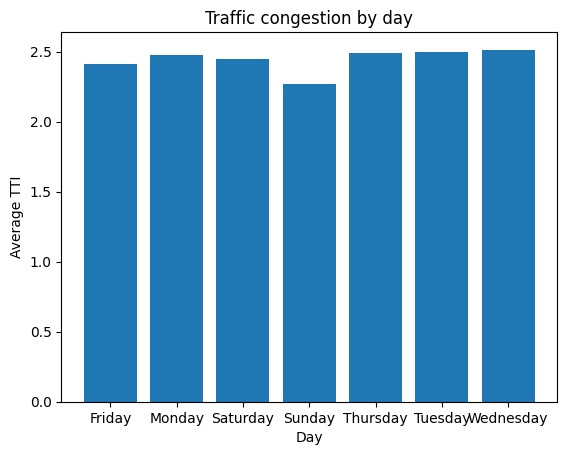

In [30]:
import matplotlib.pyplot as plt

plt.figure()

plt.bar(df_day["day"], df_day["tti_mean"])

plt.xlabel("Day")
plt.ylabel("Average TTI")
plt.title("Traffic congestion by day")

plt.show()

3️⃣ Voir les routes les plus congestionnées

In [31]:
df_roads = df_traffic.groupby("COMMUNE")["tti_mean"].mean().sort_values(ascending=False)

df_roads.head(10)

COMMUNE
Mers Sultan           3.310620
Sidi Belyout          3.293198
Al Fida               2.843337
Hay Hassani           2.764026
Ben Msick             2.752864
Assoukhour Assawda    2.721473
El Maarif             2.716806
Moulay Rachid         2.640016
Al Idrissia           2.622839
Bou Chentouf          2.548735
Name: tti_mean, dtype: float64

4️⃣ Trouver les pires trajets

In [32]:
df_worst = df_traffic.sort_values("tti_mean", ascending=False)

df_worst[[
    "COMMUNE",
    "Latitude Debut",
    "Longitude Debut",
    "Latitude Fin",
    "Longitude Fin",
    "tti_mean"
]].head(10)

,COMMUNE,Latitude Debut,Longitude Debut,Latitude Fin,Longitude Fin,tti_mean
2485,Mers Sultan,33.565338,-7.608744,33.575463,-7.594687,4.706064
1165,Mers Sultan,33.565338,-7.608744,33.575463,-7.594687,4.697410
1433,Bou Chentouf,33.557369,-7.609120,33.561224,-7.602434,4.581737
113,Bou Chentouf,33.557369,-7.609120,33.561224,-7.602434,4.565159
764,Sidi Belyout,33.588110,-7.618509,33.584778,-7.609473,4.563995
725,Mers Sultan,33.565338,-7.608744,33.575463,-7.594687,4.437473
769,Sidi Belyout,33.575368,-7.613628,33.588110,-7.618509,4.428292
1605,Mers Sultan,33.565338,-7.608744,33.575463,-7.594687,4.380535
1649,Sidi Belyout,33.575368,-7.613628,33.588110,-7.618509,4.356667
296,Mers Sultan,33.581701,-7.600926,33.574003,-7.605686,4.355460


5️⃣ Carte des trajets (optionnel mais très bien pour ton projet)

In [34]:
import folium

map_casa = folium.Map(location=[33.5731, -7.5898], zoom_start=11)

for _, row in df_traffic_clean.head(100).iterrows():

    folium.PolyLine(
        locations=[
            [row["Latitude Debut"], row["Longitude Debut"]],
            [row["Latitude Fin"], row["Longitude Fin"]]
        ],
        color="red",
        weight=2
    ).add_to(map_casa)

map_casa